In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [77]:
teta_values=[0,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009]
s_values=[]
for teta in teta_values:
    data=pd.read_csv(f"D:/tipe/tipe-2/csv-files-3/data_glob_{str(teta)}.csv")
    s=0
    for row in [row for row in data.itertuples()][196:]:
        if row.Hscore>row.Ascore:
            s+=np.log(row.proba_win)
        elif row.Hscore<row.Ascore:
            s+=np.log(row.proba_lose)
        else :
            s+=np.log(row.proba_draw)
        if row.Hscore+row.Ascore>2.5:
            s+=np.log(row.proba_O)
        else:
            s+=np.log(row.proba_U) 
    s_values.append(s)  
print(s_values)    

[-286.0239907708632, -285.370812743845, -285.07479813270317, -285.0860597292754, -285.3321452459457, -285.7515508806224, -286.30006649581156, -286.9345961676073, -287.63014325399337, -288.3684033640976]


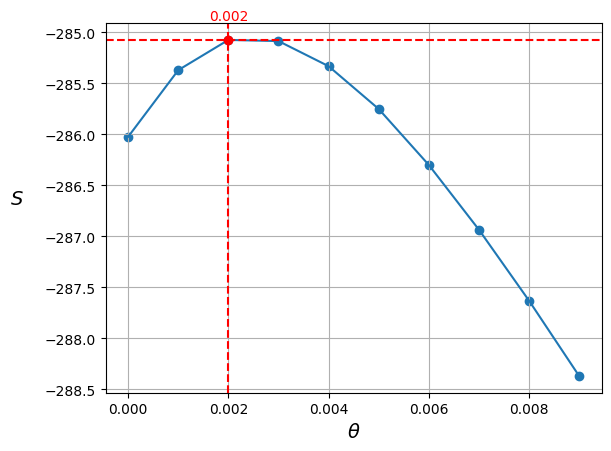

In [78]:
plt.plot(teta_values,s_values)
plt.scatter(teta_values , s_values)
max_index = s_values.index(max(s_values))
max_theta = teta_values[max_index]
max_tilde_ell = s_values[max_index]
plt.scatter(teta_values[max_index], s_values[max_index], color='r', zorder=5)
plt.axvline(x=max_theta, color='r', linestyle='--')
plt.axhline(y=max_tilde_ell, color='r', linestyle='--')
plt.text(max_theta, plt.ylim()[1], f'{max_theta}', ha='center', va='bottom', color='r')
plt.xlabel('$\\theta$', fontsize=14)
plt.ylabel('$S$', rotation=0, labelpad=20, fontsize=14)
plt.grid()
